# Preprocessing — Fruit and Vegetable Quality Classification

Prepares raw image data for CNN training: class discovery, stratified split, and augmentation configuration.

## Google Drive Setup

In [1]:
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')

DRIVE_ROOT = Path('/content/drive/MyDrive/Advanced AI/advanced-ai')

print(f'Drive root: {DRIVE_ROOT}')
print(f'Exists    : {DRIVE_ROOT.exists()}')

Mounted at /content/drive
Drive root: /content/drive/MyDrive/Advanced AI/advanced-ai
Exists    : True


## Section 1 — Imports and Configuration

All imports and configuration constants are defined here. Adjust split ratios or the small-class threshold in this cell only — all other cells read from these variables.

In [2]:
import os
import json
import random
import shutil
import datetime
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# -- Random seeds -------------------------------------------------------------
RANDOM_SEED = 42
random.seed(RANDOM_SEED)    # seed the built-in random module
np.random.seed(RANDOM_SEED) # seed NumPy; sklearn calls are seeded explicitly below

# -- Paths (all derived from DRIVE_ROOT) --------------------------------------
DATASET_ROOT = (
    DRIVE_ROOT / 'data' / 'Task 2' / 'raw' / 'Fruit And Vegetable Diseases Dataset'
)
OUTPUT_DIR      = DRIVE_ROOT / 'data' / 'Task 2' / 'processed'
CHECKPOINT_PATH = OUTPUT_DIR / 'preprocessing_checkpoint.json'

# -- Split ratios -------------------------------------------------------------
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

# -- File extensions accepted as images (suffix matching is case-normalised) --
IMG_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.JPG', '.webp'}

# -- Classes with fewer images than this threshold are flagged as small -------
SMALL_CLASS_THRESHOLD = 334  # approx half the next-smallest class (591 images)

print('Configuration summary')
print(f'  Dataset root      : {DATASET_ROOT}')
print(f'  Output directory  : {OUTPUT_DIR}')
print(f'  Checkpoint path   : {CHECKPOINT_PATH}')
print(f'  Train / val / test: {TRAIN_RATIO} / {VAL_RATIO} / {TEST_RATIO}')
print(f'  Random seed       : {RANDOM_SEED}')
print(f'  Small-class limit : {SMALL_CLASS_THRESHOLD} images')

Configuration summary
  Dataset root      : /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/raw/Fruit And Vegetable Diseases Dataset
  Output directory  : /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/processed
  Checkpoint path   : /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/processed/preprocessing_checkpoint.json
  Train / val / test: 0.7 / 0.15 / 0.15
  Random seed       : 42
  Small-class limit : 334 images


## Section 2 — Class Discovery

Walks each subdirectory of `DATASET_ROOT` to build a mapping of class name to image paths. Classes below `SMALL_CLASS_THRESHOLD` are flagged for extra augmentation at training time.

In [3]:
if not DATASET_ROOT.exists():
    raise FileNotFoundError(
        f'Dataset root not found: {DATASET_ROOT}\n'
        'Check that DRIVE_ROOT is set correctly and Google Drive is mounted.'
    )

# Build mapping: class name -> sorted list of image Paths
_normalised_exts = {ext.lower() for ext in IMG_EXTENSIONS}  # lowercase once; avoids repeated .lower() in the loop

class_images = {}
for class_dir in sorted(DATASET_ROOT.iterdir()):
    if not class_dir.is_dir():
        continue  # skip stray files at the dataset root level
    imgs = sorted(
        f for f in class_dir.iterdir()
        if f.is_file() and f.suffix.lower() in _normalised_exts
    )
    class_images[class_dir.name] = imgs

all_classes  = sorted(class_images.keys())
total_images = sum(len(v) for v in class_images.values())

print(f'Total classes found : {len(all_classes)}')
print(f'Total images found  : {total_images:,}')
print()
print(f'  {"Class":<35} {"Images":>6}')
print('  ' + '-' * 43)
for cls in all_classes:
    print(f'  {cls:<35} {len(class_images[cls]):>6}')

# Flag small classes
small_classes = [cls for cls in all_classes if len(class_images[cls]) < SMALL_CLASS_THRESHOLD]
print()
print(f'Classes below the {SMALL_CLASS_THRESHOLD}-image threshold ({len(small_classes)} found):')
for cls in small_classes:
    print(f'  {cls:<35} {len(class_images[cls]):>4} images')

Total classes found : 28
Total images found  : 29,291

  Class                               Images
  -------------------------------------------
  Apple__Healthy                        2438
  Apple__Rotten                         2930
  Banana__Healthy                       2000
  Banana__Rotten                        2800
  Bellpepper__Healthy                    611
  Bellpepper__Rotten                     591
  Carrot__Healthy                        620
  Carrot__Rotten                         580
  Cucumber__Healthy                      608
  Cucumber__Rotten                       593
  Grape__Healthy                         200
  Grape__Rotten                          200
  Guava__Healthy                         200
  Guava__Rotten                          200
  Jujube__Healthy                        200
  Jujube__Rotten                         200
  Mango__Healthy                        1813
  Mango__Rotten                         2247
  Orange__Healthy                       2075

## Section 3 — Checkpointing

Checkpoint stages mark the natural commit points in the pipeline. `save_checkpoint` writes atomically to avoid a corrupt file if the session is interrupted.

| Stage | Meaning |
|-------|---------|
| `splits_created` | Split computed in memory |
| `split_lists_saved` | Split lists written to disk |
| `complete` | All output files produced |

If the checkpoint is `complete`, all pipeline sections are skipped and only Section 7 runs.

In [4]:
CHECKPOINT_STAGES = ['splits_created', 'split_lists_saved', 'complete']

def stage_index(stage):
    """Return the ordinal position of a stage name, or -1 if not recognised."""
    try:
        return CHECKPOINT_STAGES.index(stage)
    except ValueError:
        return -1  # treat unrecognised stage names as before any named stage

def past_stage(current_stage, target_stage):
    """Return True if current_stage is strictly after target_stage."""
    if current_stage is None:
        return False
    return stage_index(current_stage) > stage_index(target_stage)

def save_checkpoint(stage, metadata=None):
    """Write a checkpoint file atomically to avoid corruption on interrupted writes."""
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    payload = {
        'stage'    : stage,
        'timestamp': datetime.datetime.now().isoformat(timespec='seconds'),
        'metadata' : metadata or {}
    }
    tmp_path = CHECKPOINT_PATH.with_suffix('.tmp')  # write to .tmp first
    with open(tmp_path, 'w', encoding='utf-8') as fh:
        json.dump(payload, fh, indent=2)
    os.replace(tmp_path, CHECKPOINT_PATH)  # atomic rename; prevents a partially-written checkpoint
    print(f'Checkpoint saved  stage="{stage}"  timestamp={payload["timestamp"]}')

# -- Check for an existing checkpoint ----------------------------------------
SKIP_ALL        = False
CURRENT_STAGE   = None
CHECKPOINT_DATA = {}

if CHECKPOINT_PATH.exists():
    with open(CHECKPOINT_PATH, 'r', encoding='utf-8') as fh:
        CHECKPOINT_DATA = json.load(fh)

    CURRENT_STAGE = CHECKPOINT_DATA.get('stage')
    meta          = CHECKPOINT_DATA.get('metadata', {})

    print('Existing checkpoint found.')
    print(f'  Stage     : {CURRENT_STAGE}')
    print(f'  Timestamp : {CHECKPOINT_DATA.get("timestamp")}')
    if meta:
        for key, val in meta.items():
            print(f'  {key}: {val}')

    if CURRENT_STAGE == 'complete':
        SKIP_ALL = True  # all pipeline stages are done; only the verification section runs
        print()
        print(
            f'Preprocessing already complete. '
            f'All output files are available at {OUTPUT_DIR}. '
            f'No further action required.'
        )
    else:
        print()
        print(
            f'Partial checkpoint detected at stage "{CURRENT_STAGE}". '
            f'Resuming from the next incomplete stage.'
        )
else:
    print('No checkpoint found. Starting preprocessing from scratch.')
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

No checkpoint found. Starting preprocessing from scratch.


## Section 3.5 — Optional Test Run

Runs the full preprocessing pipeline on 10 images per class to verify correctness before processing all 29,291 images. Outputs are written to a temporary directory and deleted at the end.

Set `RUN_TEST = True` to execute, then reset to `False` before the full run.

Test sample: 280 images across 28 classes
Preprocessing complete: 280 images processed.


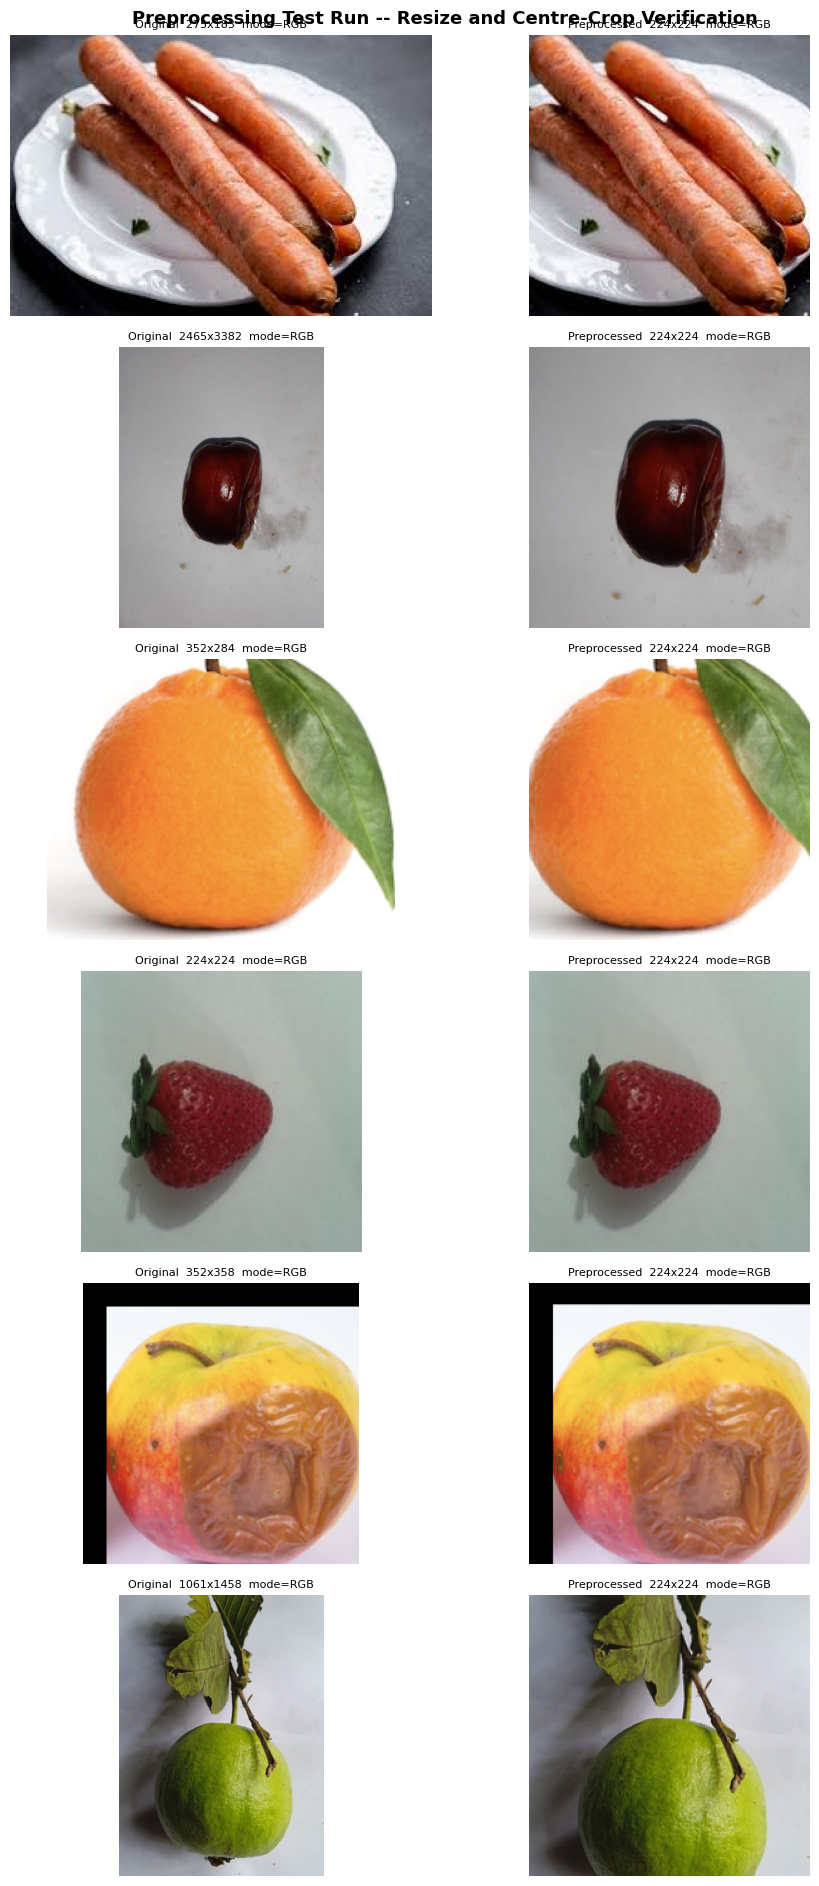


Numeric summary of all processed images:
  Class                               Orig mode    Orig size      Final size   Converted
  -------------------------------------------------------------------------------------
  Potato__Healthy                     RGB          (100, 100)     (224, 224)   no
  Potato__Healthy                     RGB          (224, 224)     (224, 224)   no
  Guava__Healthy                      RGB          (1200, 1600)   (224, 224)   no
  Cucumber__Rotten                    RGB          (275, 183)     (224, 224)   no
  Bellpepper__Rotten                  RGB          (100, 100)     (224, 224)   no
  Pomegranate__Healthy                RGB          (1525, 1801)   (224, 224)   no
  Potato__Rotten                      RGB          (300, 168)     (224, 224)   no
  Orange__Healthy                     RGB          (196, 198)     (224, 224)   no
  Guava__Rotten                       RGB          (2511, 2694)   (224, 224)   no
  Guava__Healthy                      RGB  

In [6]:
RUN_TEST = True

if not RUN_TEST:
    print('Test run skipped. Set RUN_TEST = True to execute.')
else:
    import matplotlib
    import matplotlib.pyplot as plt

    # -- Step 1: Build a small sample ------------------------------------------
    TEST_SAMPLE_PER_CLASS = 10

    test_paths  = []
    test_labels = []
    for cls in sorted(class_images.keys()):
        cls_imgs = class_images[cls]
        sample   = random.sample(cls_imgs, min(TEST_SAMPLE_PER_CLASS, len(cls_imgs)))  # min() guards classes smaller than the sample size
        for p in sample:
            test_paths.append(p)
            test_labels.append(cls)

    # Shuffle both lists together in the same way the full pipeline does.
    combined = list(zip(test_paths, test_labels))
    random.shuffle(combined)
    test_paths, test_labels = map(list, zip(*combined))  # unzip back into parallel lists

    print(f'Test sample: {len(test_paths)} images across {len(class_images)} classes')

    # -- Step 2: Apply the full preprocessing transformation -------------------
    # This is the exact transformation the training data loader will apply.
    def _preprocess_image(path):
        img = Image.open(path)
        original_mode = img.mode
        original_size = img.size  # (width, height) in pixels

        # Convert to RGB regardless of original mode (handles RGBA, L, P, etc.).
        img_rgb = img.convert('RGB')

        # Resize so the shorter edge is exactly 224, preserving aspect ratio.
        w, h = img_rgb.size
        if w <= h:
            new_w = 224
            new_h = int(round(h * 224 / w))
        else:
            new_h = 224
            new_w = int(round(w * 224 / h))
        img_resized = img_rgb.resize((new_w, new_h), Image.LANCZOS)  # LANCZOS gives highest-quality downsampling

        # Centre-crop to exactly 224x224.
        w, h   = img_resized.size
        left   = (w - 224) // 2
        top    = (h - 224) // 2
        right  = left + 224
        bottom = top  + 224
        img_cropped = img_resized.crop((left, top, right, bottom))

        return img_cropped, original_mode, original_size

    processed_results = []
    for path, label in zip(test_paths, test_labels):
        original_img                        = Image.open(path)
        preprocessed, orig_mode, orig_size  = _preprocess_image(path)
        processed_results.append((
            original_img.convert('RGB'),  # converted copy for display only
            preprocessed,
            orig_mode,
            orig_size,
            label
        ))

    print(f'Preprocessing complete: {len(processed_results)} images processed.')

    # -- Step 3: Visualise results ---------------------------------------------
    # Select 6 classes, guaranteeing at least one small and one large class.
    _large_classes = [c for c in all_classes if c not in small_classes]
    _guaranteed    = []
    if small_classes:
        _guaranteed.append(random.choice(small_classes))
    if _large_classes:
        _guaranteed.append(random.choice(_large_classes))
    _remaining   = [c for c in all_classes if c not in _guaranteed]
    _extra       = random.sample(_remaining, min(4, len(_remaining)))
    _viz_classes = (_guaranteed + _extra)[:6]
    random.shuffle(_viz_classes)

    _viz_items = []
    for cls in _viz_classes:
        _candidates = [
            item for item in processed_results if item[4] == cls
        ]
        if _candidates:
            _viz_items.append(random.choice(_candidates))

    _n_rows = len(_viz_items)
    fig, axes = plt.subplots(_n_rows, 2, figsize=(10, _n_rows * 3.2))
    fig.suptitle(
        'Preprocessing Test Run -- Resize and Centre-Crop Verification',
        fontsize=13, fontweight='bold'
    )
    if _n_rows == 1:
        axes = [axes]  # ensure axes is always a list of rows for consistent indexing

    for _row, (orig, pre, mode, size, label) in enumerate(_viz_items):
        ax_orig = axes[_row][0]
        ax_pre  = axes[_row][1]

        ax_orig.imshow(orig)
        ax_orig.set_title(f'Original  {size[0]}x{size[1]}  mode={mode}', fontsize=8)
        ax_orig.axis('off')
        ax_orig.set_ylabel(
            label.replace('__', '\n'),
            rotation=0, labelpad=90, fontsize=7,
            ha='right', va='center'
        )

        ax_pre.imshow(pre)
        ax_pre.set_title(
            f'Preprocessed  {pre.size[0]}x{pre.size[1]}  mode=RGB', fontsize=8
        )
        ax_pre.axis('off')

    plt.tight_layout()
    plt.show()

    # -- Step 4: Numeric summary -----------------------------------------------
    print()
    print('Numeric summary of all processed images:')
    print(
        f'  {"Class":<35} {"Orig mode":<12} {"Orig size":<14} '
        f'{"Final size":<12} Converted'
    )
    print('  ' + '-' * 85)

    _n_converted    = 0
    _n_already_rgb  = 0
    _all_224        = True

    for _orig, _pre, _mode, _orig_size, _label in processed_results:
        _converted = _mode != 'RGB'
        if _converted:
            _n_converted += 1
        else:
            _n_already_rgb += 1
        _final = _pre.size
        if _final != (224, 224):
            _all_224 = False  # flag if any image did not reach the expected output size
        print(
            f'  {_label:<35} {_mode:<12} {str(_orig_size):<14} '
            f'{str(_final):<12} {"yes" if _converted else "no"}'
        )

    print()
    print(f'Images requiring conversion from non-RGB : {_n_converted}')
    print(f'Images already in RGB mode               : {_n_already_rgb}')
    print(f'All output images exactly 224x224        : {_all_224}')

    # -- Step 5: Stratified split on test sample ------------------------------
    print()
    print('Running stratified split on test sample...')

    # Identical two-step split logic as Section 4.
    (
        _s_train_paths, _s_holdout_paths,
        _s_train_labels, _s_holdout_labels
    ) = train_test_split(
        test_paths, test_labels,
        test_size=1.0 - TRAIN_RATIO,
        stratify=test_labels,
        random_state=RANDOM_SEED
    )
    (
        _s_val_paths, _s_test_paths,
        _s_val_labels, _s_test_labels
    ) = train_test_split(
        _s_holdout_paths, _s_holdout_labels,
        test_size=0.50,  # split holdout 50/50 into val and test
        stratify=_s_holdout_labels,
        random_state=RANDOM_SEED
    )

    _s_train_samples = list(zip(_s_train_paths, _s_train_labels))
    _s_val_samples   = list(zip(_s_val_paths,   _s_val_labels))
    _s_test_samples  = list(zip(_s_test_paths,  _s_test_labels))

    _s_total = len(test_paths)
    print(f'  Train : {len(_s_train_samples):>4}  ({100*len(_s_train_samples)/_s_total:.1f}%)')
    print(f'  Val   : {len(_s_val_samples):>4}  ({100*len(_s_val_samples)/_s_total:.1f}%)')
    print(f'  Test  : {len(_s_test_samples):>4}  ({100*len(_s_test_samples)/_s_total:.1f}%)')

    # Write to temp dir using identical JSON structure to Section 5.
    _test_tmp_dir = OUTPUT_DIR / 'test_run_tmp'
    _test_tmp_dir.mkdir(parents=True, exist_ok=True)

    _s_split_data = {
        'train': [{'filepath': str(p), 'label': l} for p, l in _s_train_samples],
        'val'  : [{'filepath': str(p), 'label': l} for p, l in _s_val_samples],
        'test' : [{'filepath': str(p), 'label': l} for p, l in _s_test_samples],
    }
    _s_split_path = _test_tmp_dir / 'split_lists.json'
    with open(_s_split_path, 'w', encoding='utf-8') as fh:
        json.dump(_s_split_data, fh, indent=2)

    _sorted_test_classes = sorted(set(test_labels))
    _s_class_info = {
        'class_names'   : _sorted_test_classes,
        'class_to_index': {c: i for i, c in enumerate(_sorted_test_classes)},
        'small_classes' : [c for c in small_classes if c in _sorted_test_classes],
        'image_counts'  : {c: test_labels.count(c) for c in _sorted_test_classes},
    }
    _s_info_path = _test_tmp_dir / 'class_info.json'
    with open(_s_info_path, 'w', encoding='utf-8') as fh:
        json.dump(_s_class_info, fh, indent=2)

    # Load back and verify deserialisation.
    with open(_s_split_path, 'r', encoding='utf-8') as fh:
        _s_loaded = json.load(fh)
    with open(_s_info_path, 'r', encoding='utf-8') as fh:
        _s_loaded_info = json.load(fh)

    assert set(_s_loaded.keys()) == {'train', 'val', 'test'}, \
        'split_lists.json missing expected keys'
    assert 'class_names' in _s_loaded_info, \
        'class_info.json missing class_names key'
    print('  Deserialisation check passed.')

    # Per-class split breakdown.
    _s_train_cls = Counter(s['label'] for s in _s_loaded['train'])
    _s_val_cls   = Counter(s['label'] for s in _s_loaded['val'])
    _s_test_cls  = Counter(s['label'] for s in _s_loaded['test'])

    print()
    print('Per-class split breakdown (test sample):')
    print(f'  {"Class":<35} {"Train":>6} {"Val":>5} {"Test":>5}')
    print('  ' + '-' * 55)

    _s_zero_classes = []
    for cls in _sorted_test_classes:
        t  = _s_train_cls[cls]
        v  = _s_val_cls[cls]
        te = _s_test_cls[cls]
        if t == 0 or v == 0 or te == 0:
            _s_zero_classes.append(cls)  # with only 10 images per class, zeros are expected for small splits
        print(f'  {cls:<35} {t:>6} {v:>5} {te:>5}')

    print()
    if _s_zero_classes:
        print(
            'Warning: zero samples in at least one split for: '
            + str(_s_zero_classes)
        )
        print(
            'Note: this is expected with very small per-class sample sizes '
            'and does not indicate a bug in the split logic.'
        )
    else:
        print('All classes represented in every split.')

    # -- Step 6: Delete temporary directory -----------------------------------
    shutil.rmtree(_test_tmp_dir)  # remove all test outputs so they do not interfere with the real pipeline
    print()
    print(
        'Test run complete. All temporary files deleted. '
        'No checkpoint written. Safe to proceed with the full pipeline.'
    )

## Section 4 — Stratified Train / Val / Test Split

Splits images 70 / 15 / 15 using a two-step stratified procedure: first 70% train vs 30% holdout, then the holdout split 50 / 50 into val and test. Stratification preserves class proportions in every subset.

Skipped if the checkpoint shows splits have already been saved; in that case the existing lists are loaded from disk.

In [7]:
if SKIP_ALL or past_stage(CURRENT_STAGE, 'splits_created'):
    # Splits already saved to disk -- load them so later sections have access.
    print('Section 4 skipped: loading existing split lists from disk.')
    _split_json = OUTPUT_DIR / 'split_lists.json'
    with open(_split_json, 'r', encoding='utf-8') as fh:
        _split_data = json.load(fh)
    train_samples = [(Path(s['filepath']), s['label']) for s in _split_data['train']]
    val_samples   = [(Path(s['filepath']), s['label']) for s in _split_data['val']]
    test_samples  = [(Path(s['filepath']), s['label']) for s in _split_data['test']]
    print(
        f'Loaded  train={len(train_samples):,}  '
        f'val={len(val_samples):,}  '
        f'test={len(test_samples):,}'
    )
else:
    # Build flat lists of paths and labels, maintaining a consistent ordering.
    all_paths  = []
    all_labels = []
    for cls in sorted(class_images.keys()):
        for p in class_images[cls]:
            all_paths.append(p)
            all_labels.append(cls)

    # Shuffle both lists together before splitting to remove directory-order bias.
    combined = list(zip(all_paths, all_labels))
    random.shuffle(combined)
    all_paths, all_labels = map(list, zip(*combined))  # unzip back into parallel lists

    # Step 1: 70% train, 30% temporary holdout.
    train_paths, holdout_paths, train_labels, holdout_labels = train_test_split(
        all_paths, all_labels,
        test_size=1.0 - TRAIN_RATIO,
        stratify=all_labels,  # preserves class proportions in both halves
        random_state=RANDOM_SEED
    )

    # Step 2: split holdout evenly into val and test (15% / 15% of total).
    val_paths, test_paths, val_labels, test_labels = train_test_split(
        holdout_paths, holdout_labels,
        test_size=0.50,  # 50% of holdout = 15% of total
        stratify=holdout_labels,
        random_state=RANDOM_SEED
    )

    train_samples = list(zip(train_paths, train_labels))
    val_samples   = list(zip(val_paths,   val_labels))
    test_samples  = list(zip(test_paths,  test_labels))

    total = len(all_paths)
    print('Split counts:')
    print(f'  Train : {len(train_samples):>6,}  ({100*len(train_samples)/total:.1f}%)')
    print(f'  Val   : {len(val_samples):>6,}  ({100*len(val_samples)/total:.1f}%)')
    print(f'  Test  : {len(test_samples):>6,}  ({100*len(test_samples)/total:.1f}%)')

    # Per-class breakdown to verify stratification.
    train_cls_counts = Counter(label for _, label in train_samples)
    val_cls_counts   = Counter(label for _, label in val_samples)
    test_cls_counts  = Counter(label for _, label in test_samples)

    print()
    print('Per-class split verification:')
    print(f'  {"Class":<35} {"Train":>6} {"Val":>5} {"Test":>5} {"Total":>6}')
    print('  ' + '-' * 58)
    for cls in sorted(all_classes):
        t  = train_cls_counts[cls]
        v  = val_cls_counts[cls]
        te = test_cls_counts[cls]
        print(f'  {cls:<35} {t:>6} {v:>5} {te:>5} {t+v+te:>6}')

    save_checkpoint('splits_created', {
        'total_images': total,
        'train_count' : len(train_samples),
        'val_count'   : len(val_samples),
        'test_count'  : len(test_samples),
    })
    CURRENT_STAGE = 'splits_created'

Split counts:
  Train : 20,503  (70.0%)
  Val   :  4,394  (15.0%)
  Test  :  4,394  (15.0%)

Per-class split verification:
  Class                                Train   Val  Test  Total
  ----------------------------------------------------------
  Apple__Healthy                        1707   366   365   2438
  Apple__Rotten                         2051   440   439   2930
  Banana__Healthy                       1400   300   300   2000
  Banana__Rotten                        1960   420   420   2800
  Bellpepper__Healthy                    428    91    92    611
  Bellpepper__Rotten                     414    88    89    591
  Carrot__Healthy                        434    93    93    620
  Carrot__Rotten                         406    87    87    580
  Cucumber__Healthy                      426    91    91    608
  Cucumber__Rotten                       415    89    89    593
  Grape__Healthy                         140    30    30    200
  Grape__Rotten                          140    

## Section 5 — Save Split Lists

Writes two JSON files to `OUTPUT_DIR`:

- **`split_lists.json`** — train / val / test entries, each with `filepath` and `label`.
- **`class_info.json`** — class names, integer index mapping, small-class list, and per-class image counts.

In [8]:
if SKIP_ALL:
    print('Section 5 skipped: preprocessing is already complete.')
else:
    # -- split_lists.json -----------------------------------------------------
    split_data = {
        'train': [{'filepath': str(p), 'label': l} for p, l in train_samples],
        'val'  : [{'filepath': str(p), 'label': l} for p, l in val_samples],
        'test' : [{'filepath': str(p), 'label': l} for p, l in test_samples],
    }
    split_path = OUTPUT_DIR / 'split_lists.json'
    with open(split_path, 'w', encoding='utf-8') as fh:
        json.dump(split_data, fh, indent=2)

    # -- class_info.json ------------------------------------------------------
    sorted_classes = sorted(all_classes)
    class_info = {
        'class_names'   : sorted_classes,
        'class_to_index': {cls: idx for idx, cls in enumerate(sorted_classes)},  # integer label for one-hot encoding
        'small_classes' : small_classes,
        'image_counts'  : {cls: len(class_images[cls]) for cls in all_classes},
    }
    info_path = OUTPUT_DIR / 'class_info.json'
    with open(info_path, 'w', encoding='utf-8') as fh:
        json.dump(class_info, fh, indent=2)

    split_size = split_path.stat().st_size
    info_size  = info_path.stat().st_size
    print(f'Saved split_lists.json  : {split_size:>10,} bytes')
    print(f'  Path: {split_path}')
    print(f'Saved class_info.json   : {info_size:>10,} bytes')
    print(f'  Path: {info_path}')

    save_checkpoint('split_lists_saved', {
        'total_images'     : len(train_samples) + len(val_samples) + len(test_samples),
        'train_count'      : len(train_samples),
        'val_count'        : len(val_samples),
        'test_count'       : len(test_samples),
        'split_lists_path' : str(split_path),
        'class_info_path'  : str(info_path),
    })
    CURRENT_STAGE = 'split_lists_saved'

Saved split_lists.json  :  6,278,435 bytes
  Path: /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/processed/split_lists.json
Saved class_info.json   :      2,494 bytes
  Path: /content/drive/MyDrive/Advanced AI/advanced-ai/data/Task 2/processed/class_info.json
Checkpoint saved  stage="split_lists_saved"  timestamp=2026-04-09T10:04:46


## Section 6 — Augmentation Configuration

Records the agreed augmentation parameters as `augmentation_config.json` so the training notebook can load them directly.

Two levels are defined: **standard** (applied to all classes) and **small-class additional** (applied on top, only to the eight classes with 200 images). Augmentation runs at training time on the GPU and is disabled during validation and inference.

In [9]:
if SKIP_ALL:
    print('Section 6 skipped: preprocessing is already complete.')
else:
    aug_config = {
        'standard': {
            'description' : 'Applied to all classes during training.',
            'RandomFlip'     : {'mode'         : 'horizontal'},
            'RandomRotation' : {'factor'        : 0.1},
            'RandomZoom'     : {'height_factor' : 0.1},
            'RandomContrast' : {'factor'        : 0.1},
        },
        'small_class_additional': {
            'description' : (
                'Applied additionally to small classes only, '
                'on top of the standard augmentation set.'
            ),
            'applies_to'      : small_classes,  # the 8 classes with only 200 images each
            'RandomFlip'      : {'mode'         : 'vertical'},
            'RandomRotation'  : {'factor'        : 0.2},  # wider range than standard
            'RandomZoom'      : {'height_factor' : 0.2},
            'RandomBrightness': {'factor'        : 0.2},
        },
    }

    aug_path = OUTPUT_DIR / 'augmentation_config.json'
    with open(aug_path, 'w', encoding='utf-8') as fh:
        json.dump(aug_config, fh, indent=2)

    print('Augmentation configuration:')
    print(json.dumps(aug_config, indent=2))
    print()
    print(f'Saved augmentation_config.json  : {aug_path.stat().st_size:,} bytes')
    print(f'  Path: {aug_path}')


    print()
    print(
        'Note on RGBA images: the split lists produced by this notebook include '
        'file paths to images that may be in RGBA format (four-channel, with an '
        'alpha channel). The training notebook must convert all images to RGB '
        'using PIL Image.convert(\'RGB\') before passing them to the model. '
        'Based on the dataset audit, approximately 6 out of every 200 sampled '
        'images required conversion, extrapolating to roughly 900 files across '
        'the full dataset of 29,291 images.'
    )
    save_checkpoint('complete', {
        'output_dir'     : str(OUTPUT_DIR),
        'files_produced' : [
            'preprocessing_checkpoint.json',
            'split_lists.json',
            'class_info.json',
            'augmentation_config.json',
        ],
    })
    CURRENT_STAGE = 'complete'
    SKIP_ALL      = True  # prevent subsequent cells from re-running pipeline stages

Augmentation configuration:
{
  "standard": {
    "description": "Applied to all classes during training.",
    "RandomFlip": {
      "mode": "horizontal"
    },
    "RandomRotation": {
      "factor": 0.1
    },
    "RandomZoom": {
      "height_factor": 0.1
    },
    "RandomContrast": {
      "factor": 0.1
    }
  },
  "small_class_additional": {
    "description": "Applied additionally to small classes only, on top of the standard augmentation set.",
    "applies_to": [
      "Grape__Healthy",
      "Grape__Rotten",
      "Guava__Healthy",
      "Guava__Rotten",
      "Jujube__Healthy",
      "Jujube__Rotten",
      "Pomegranate__Healthy",
      "Pomegranate__Rotten"
    ],
    "RandomFlip": {
      "mode": "vertical"
    },
    "RandomRotation": {
      "factor": 0.2
    },
    "RandomZoom": {
      "height_factor": 0.2
    },
    "RandomBrightness": {
      "factor": 0.2
    }
  }
}

Saved augmentation_config.json  : 873 bytes
  Path: /content/drive/MyDrive/Advanced AI/advanced-a

## Section 7 — Verification

Loads all output files from disk and confirms that every class has at least one sample in each split.

In [10]:
print('Loading output files for verification...')
print()

split_path = OUTPUT_DIR / 'split_lists.json'
info_path  = OUTPUT_DIR / 'class_info.json'
aug_path   = OUTPUT_DIR / 'augmentation_config.json'

for label, path in [
    ('split_lists.json',         split_path),
    ('class_info.json',          info_path),
    ('augmentation_config.json', aug_path),
]:
    if not path.exists():
        raise FileNotFoundError(f'Expected output file not found: {path}')

with open(split_path, 'r', encoding='utf-8') as fh:
    split_data = json.load(fh)

with open(info_path, 'r', encoding='utf-8') as fh:
    loaded_class_info = json.load(fh)

with open(aug_path, 'r', encoding='utf-8') as fh:
    loaded_aug_config = json.load(fh)

train_loaded = split_data['train']
val_loaded   = split_data['val']
test_loaded  = split_data['test']
total_loaded = len(train_loaded) + len(val_loaded) + len(test_loaded)

counts     = loaded_class_info['image_counts']
majority_n = max(counts.values())  # most images in any single class
minority_n = min(counts.values())  # fewest images in any single class
imbalance  = majority_n / minority_n  # ratio indicating how skewed the dataset is

print('=' * 56)
print('  Summary')
print('=' * 56)
print(f'  Total images          : {total_loaded:,}')
print(f'  Train                 : {len(train_loaded):,}  ({100*len(train_loaded)/total_loaded:.1f}%)')
print(f'  Val                   : {len(val_loaded):,}  ({100*len(val_loaded)/total_loaded:.1f}%)')
print(f'  Test                  : {len(test_loaded):,}  ({100*len(test_loaded)/total_loaded:.1f}%)')
print(f'  Classes               : {len(loaded_class_info["class_names"])}')
print(f'  Small classes         : {len(loaded_class_info["small_classes"])}')
print(f'  Imbalance ratio       : {imbalance:.1f}x  '
      f'(majority={majority_n:,}, minority={minority_n:,})')
print('=' * 56)

# Per-class breakdown
train_cls = Counter(s['label'] for s in train_loaded)
val_cls   = Counter(s['label'] for s in val_loaded)
test_cls  = Counter(s['label'] for s in test_loaded)

print()
print('Per-class split breakdown:')
print(f'  {"Class":<35} {"Train":>6} {"Val":>5} {"Test":>5}')
print('  ' + '-' * 55)

zero_sample_classes = []
for cls in loaded_class_info['class_names']:
    t  = train_cls[cls]
    v  = val_cls[cls]
    te = test_cls[cls]
    if t == 0 or v == 0 or te == 0:
        zero_sample_classes.append(cls)
    print(f'  {cls:<35} {t:>6} {v:>5} {te:>5}')

print()
if zero_sample_classes:
    print(
        'WARNING: the following classes have zero samples in at least one split '
        'and must be addressed before training: '
        + str(zero_sample_classes)
    )
else:
    print('Verification passed: all classes have at least one sample in every split.')

# Output file listing
print()
print('Output files:')
output_files = [
    'preprocessing_checkpoint.json',
    'split_lists.json',
    'class_info.json',
    'augmentation_config.json',
]
for fname in output_files:
    p      = OUTPUT_DIR / fname
    size   = p.stat().st_size if p.exists() else 0
    status = f'{size:>12,} bytes' if p.exists() else '       NOT FOUND'
    print(f'  {status}   {p}')

Loading output files for verification...

  Summary
  Total images          : 29,291
  Train                 : 20,503  (70.0%)
  Val                   : 4,394  (15.0%)
  Test                  : 4,394  (15.0%)
  Classes               : 28
  Small classes         : 8
  Imbalance ratio       : 14.7x  (majority=2,930, minority=200)

Per-class split breakdown:
  Class                                Train   Val  Test
  -------------------------------------------------------
  Apple__Healthy                        1707   366   365
  Apple__Rotten                         2051   440   439
  Banana__Healthy                       1400   300   300
  Banana__Rotten                        1960   420   420
  Bellpepper__Healthy                    428    91    92
  Bellpepper__Rotten                     414    88    89
  Carrot__Healthy                        434    93    93
  Carrot__Rotten                         406    87    87
  Cucumber__Healthy                      426    91    91
  Cucumber__Ro